This notebook focuses on understanding, cleaning, transforming, and engineering features from the UCI Bank Marketing dataset to prepare it for predictive modeling.


**Task 1: Identifying the Prediction Target**


As stated in the assignment description, the business objective of the telemarketing campaign is to determine whether a contacted client subscribes to a term deposit. In the dataset, this outcome is represented by the variable y, which takes the values "yes" or "no". Therefore, y will be treated as the target variable in this analysis.

From a machine learning perspective, this problem falls under the category of classification, since the objective is to assign each client to one of two predefined classes: subscription ("yes") or no subscription ("no").



Although many other variables may superficially appear to be potential targets, they do not align with the business objective of the campaign. For example, variables such as loan, housing, or default describe the client’s financial status rather than the outcome of the marketing campaign. Predicting these variables would correspond to solving a different business problem.

Similarly, poutcome (the outcome of a previous campaign) contains relevant historical information and may be useful as a predictor, but it does not represent the outcome of the current marketing campaign. Therefore, it does not align with the stated business objective and should not be treated as the target variable either.


**Task 2: Data Loading and Exploration**

In [60]:
import pandas as pd
df = pd.read_csv("data/bank-additional.csv", sep=";")

In [61]:
df.shape

(4119, 21)

The dataset was loaded into a pandas DataFrame. Using df.shape, we observe that the dataset contains 4,119 observations and 21 variables, including the target variable y.

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Based on the output of df.info(), the dataset contains 10 numerical variables (five stored as int64 and five as float64) and 11 categorical variables stored as object (string) type.

The numerical variables include demographic attributes such as age, campaign-related variables such as duration, campaign, pdays, and previous, as well as macroeconomic indicators including emp.var.rate, cons.conf.idx, euribor3m, and nr.employed.

The categorical variables include demographic characteristics such as job, marital, and education, financial attributes such as default, housing, and loan, campaign descriptors such as contact, month, day_of_week, and poutcome, as well as the target variable y.

All variables report 4,119 non-null values, indicating that there are no explicitly missing values in the dataset. However, some categorical variables may contain entries such as "unknown", which could represent implicit missing values. We will investigate this later.

In [66]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The basic summary statistics for the numerical variables were obtained using df.describe(). These statistics provide information about the central tendency and dispersion of the variables (mean, standard deviation, min, max…)

For example, the average client age is approximately 40 years, with values ranging from 18 to 88. The variable duration shows a wide range and a relatively high standard deviation which indicates high variability in call length

Campaign-related variables like campaign and previous are highly skewed, as most clients were contacted only a few times. Moreover, the variable pdays frequently takes the value 999, which likely represents a special category rather than an actual number of days.

One variable that requires special consideration is duration, which represents the length of the phone call. This information is only available after the call has ended and would not be known at the time of making a prediction. Therefore, including this variable in the model could introduce data leakage, because it contains information that would not be available in a real-world prediction scenario.

Also, macroeconomic variables such as euribor3m and nr.employed are measured on very different numerical scales. As a result, feature scaling may be necessary before training the model.

In [9]:
df.describe(include='string')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


The categorical summary statistics obtained using df.describe(include='object') reveal several important patterns. Some variables, such as y, look binary since they contain only two categories. Others, such as job, education, and month, contain multiple categories.

Although variables like default, housing, and loan conceptually represent binary attributes, they contain three categories. The additional category (e.g., "unknown") likely represents implicit missing values rather than a true third class.

Additionally, the variable poutcome is dominated by the category "nonexistent" which indicates that most clients were not contacted in a previous campaign.

Many categorical variables are highly imbalanced. For example, the majority of observations in default, housing, and loan correspond to the category "no". This imbalance may influence model performance and should be considered during preprocessing.

Class counts:
 y
no     3668
yes     451
Name: count, dtype: int64

Class fractions:
 y
no     0.8905
yes    0.1095
Name: proportion, dtype: float64


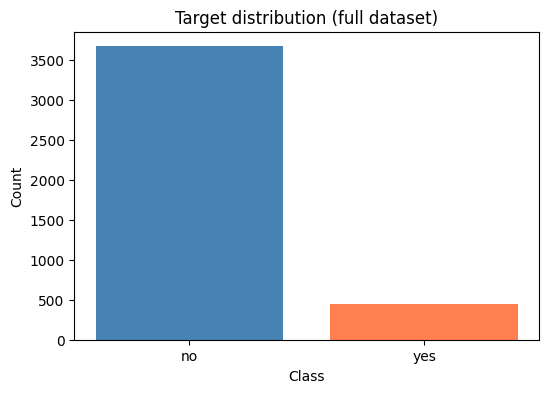


Imbalance ratio (minority/majority): 0.1230


In [20]:
import matplotlib.pyplot as plt

# Class balance
class_counts = df["y"].value_counts()
class_fractions = df["y"].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass fractions:\n", class_fractions.round(4))

# Bar chart of class distribution
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values,color=["steelblue", "coral"])
plt.title("Target distribution (full dataset)")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

# Quantify imbalance
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"\nImbalance ratio (minority/majority): {imbalance_ratio:.4f}")

An important step in exploratory analysis is checking the distribution of the target variable y to determine whether it is balanced or if one class dominates the other. The distribution plot clearly shows that the dataset is imbalanced.

Out of 4,119 observations, 3,668 correspond to clients who did not subscribe ("no"), while only 451 correspond to clients who subscribed ("yes"). This represents approximately 89.05% of the data in the majority class and 10.95% in the minority class.

The imbalance ratio is approximately 0.123, indicating that the minority class is strongly underrepresented. This may affect model performance. Therefore, when splitting the data into training and test sets, we will use stratified sampling to preserve the original class distribution in both subsets.

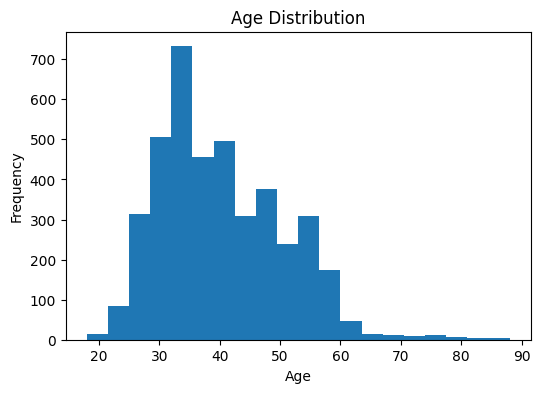

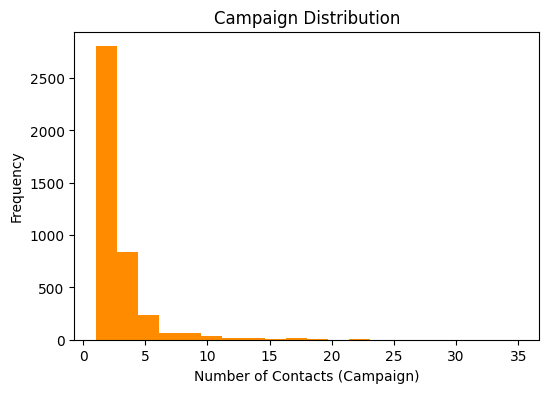

In [37]:
import matplotlib.pyplot as plt

# Age distribution
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Campaign distribution
plt.figure(figsize=(6, 4))
plt.hist(df["campaign"], bins=20, color="darkorange")
plt.title("Campaign Distribution")
plt.xlabel("Number of Contacts (Campaign)")
plt.ylabel("Frequency")
plt.show()

The distribution of age appears to be centered around middle adulthood, with most clients between approximately 30 and 50 years old. The distribution is slightly right-skewed, as there are fewer older clients above 60.

In contrast, the variable campaign is strongly right-skewed. Most clients were contacted only a small number of times, while a few clients were contacted many times. This suggests the presence of extreme values, which may require careful consideration during modeling.

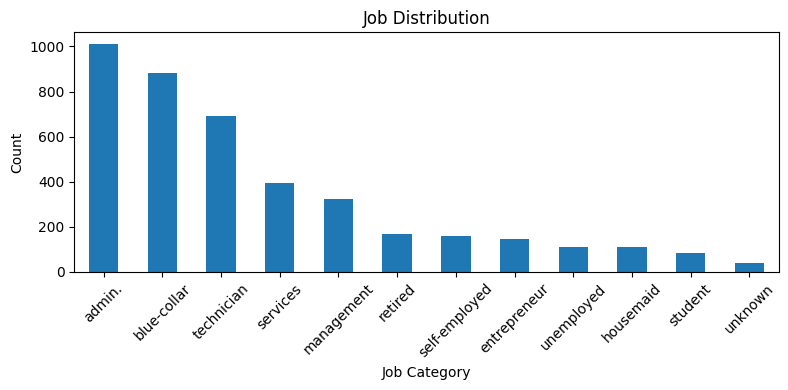

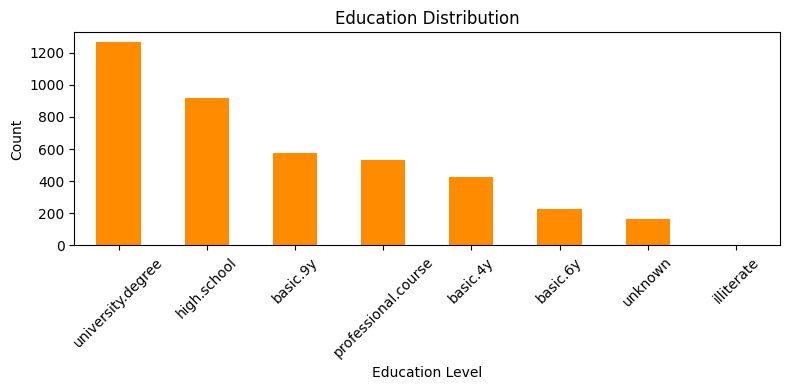

In [27]:
import matplotlib.pyplot as plt

# Job distribution
plt.figure(figsize=(8, 4))
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.xlabel("Job Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Education distribution
plt.figure(figsize=(8, 4))
df["education"].value_counts().plot(kind="bar", color="darkorange")
plt.title("Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The job distribution shows that the dataset is dominated by a few occupations, particularly admin. and blue-collar, while other categories such as student and unknown are much less represented. This indicates an uneven distribution across occupational groups.

Similarly, the education distribution indicates that most clients have either a university degree or a high school education, whereas categories such as illiterate are very rare.

In both variables, there is a category labeled "unknown", which likely represents implicit missing values rather than a meaningful additional group.

Overall, both variables exhibit imbalanced category distributions, which may influence the modeling process, particularly during encoding and when interpreting feature importance.

**Task 3: Task Ordering**

The order in which data preparation steps are performed is critical to ensure a valid and unbiased evaluation of the model. In supervised learning, any step that learns information from the data must be performed using only the training set after the dataset has been split. Otherwise, information from the test set may leak into the training process, leading to overly optimistic performance estimates.

The correct sequence for this assignment is the following:

**1. Target Identification**

The dataset is first loaded, and the prediction target is identified based on the business objective. In this case, the variable y, indicating whether a client subscribes to a term deposit, is selected as the target.

At this stage, the full dataset may be inspected because no statistical relationships are being estimated and no model parameters are being learned. So, there is no risk of statistical data leakage.

**2. Exploratory Data Analysis**

Exploratory data analysis is conducted to understand the structure and characteristics of the dataset. During this stage, it is also important to assess potential data leakage risks. In supervised learning, leakage can arise from target leakage, proxy features, or temporal leakage.

In this dataset, the primary concern is temporal leakage related to the variable duration, which represents the length of the phone call and is only known after the call has ended. Since the objective is to predict subscription at the time of contact, including this variable would introduce future information into the model. Therefore, duration must be removed before proceeding to data splitting and model training to ensure a realistic evaluation.

**3. Data Splitting**

The dataset is then split into training, validation, and test sets using stratification to preserve the class distribution of the target variable. The training set is used to fit preprocessing steps and model parameters. The validation set is used for model tuning and comparison, while the test set is reserved exclusively for the final evaluation. From this stage forward, the test set must remain completely unseen until the final performance assessment.

The split must occur before any preprocessing step that estimates parameters from the data. If splitting were performed later, information leakage through preprocessing could occur, since the training process would indirectly use information from the validation or test sets. This would lead to overly optimistic evaluation results.

Moreover, when splitting the data, it is important to consider potential group leakage. This can occur when multiple observations correspond to the same entity, such as the same client, and related observations appear across different subsets. In this dataset, each row represents an individual campaign contact and no explicit grouping variable is provided, so standard splitting is appropriate and group leakage is unlikely to be an issue.

**4. Preprocessing After Data Splitting**

After splitting the data into training, validation, and test sets, any preprocessing step that learns something from the data must be done using only the training set.

The tasks inside this section include:

**4.1 Handling Missing Values**

This step involves addressing both explicit and implicit missing values. Although no explicit missing values are present, implicit missingness was identified during exploration. We can use different strategies at this stage, such as imputation or treating missing values as a separate category. If imputation is applied, the imputation statistics must be computed using only the training set and then applied to the validation and test sets. Otherwise, information from the validation or test data would influence the training process, leading to preprocessing leakage.

**4.2 Encoding Categorical Variables**

After handling missing values and special codes, categorical variables must be transformed into a numeric format, for example using one-hot encoding. It is important to address missingness first to ensure that the categorical values are consistent before being encoded.
The encoder must be fitted only on the training set and then applied to the validation and test sets. If we were to fit the encoder on the full dataset, we would be using information from the validation or test data during training. This would influence the feature representation and result in information leakage.

**4.3 Addressing class imbalance**

After encoding the categorical variables, we can address the class imbalance issue. This step is performed after encoding because more advanced resampling techniques such as SMOTE or ADASYN require numeric input, since they generate synthetic observations based on distances in the feature space.

Resampling must be applied only to the training set. If it were performed before splitting the data, duplicated or artificially generated observations could end up in both the training and test sets. This would violate the independence of the test set and lead to overly optimistic performance estimates.

**4.4 Feature Scaling**

After addressing class imbalance, we can scale numerical variables if required. Scaling is performed at this stage so that it is applied to the final version of the training data, after any resampling has been completed.

If scaling is needed, for example through standardization or normalization, the scaling parameters must be computed using only the training set and then applied to the validation and test sets. Otherwise, the training data would be scaled using statistics from the validation or test data, which would introduce information leakage through preprocessing and result in an overly optimistic model evaluation.

**4.5 Feature Selection**

After all the previous steps, we can perform feature selection. This step is done at this stage so that selection is based on the final representation of the training data.

Any feature selection method that relies on data-driven criteria, such as correlations or statistical tests, must be carried out using only the training set. If feature selection were performed on the full dataset before splitting, the test set would influence which features are retained. This would result in information leakage and overly optimistic evaluation results.


After all these steps, we can proceed to train the model on the training data and then use validation and test (only once) sets to evaluate it.

**Task 4: Data Splitting**

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["y"])
y = df["y"]

# 1) First split: Train and temporary (train = 60%, temp = 40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42,
    stratify=y,
)

# 2) Second split: split temporary into test (20%) and validation (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

df = pd.DataFrame({
"Set": ["Train", "Validation", "Test"],
"X shape": [X_train.shape, X_val.shape, X_test.shape],
"y shape": [y_train.shape, y_val.shape, y_test.shape],
})
display(df.style.hide(axis="index"))

Set,X shape,y shape
Train,"(2471, 20)","(2471,)"
Validation,"(824, 20)","(824,)"
Test,"(824, 20)","(824,)"


The dataset was split into 60% training, 20% validation, and 20% test sets. This choice was made following the guideline that validation and test sets must be large enough to provide reliable evaluation statistics. In this dataset, the minority class (“yes”) contains 451 observations. Allocating 20% to both validation and test results in approximately 90 minority examples in each set. This is well above the minimum guideline of around 12 observations per class and close to the commonly suggested threshold of 100 per class for reliable evaluation. At the same time, the training set retains approximately 270 minority examples, which is enough for training a shallow model such as logistic regression, since such models generally require less data than more complex models.

Stratified splitting was performed with respect to the target variable y. As discussed earlier, the dataset is clearly imbalanced. Without stratification, random splitting could result in validation or test sets containing too few positive examples, which would lead to unstable and potentially misleading evaluation metrics. Stratification ensures that each subset preserves the original class distribution.

The split was performed after exploratory analysis but before any preprocessing steps that estimate parameters from the data. Splitting must occur at this stage to ensure that the validation and test sets remain independent. If splitting were performed later, preprocessing statistics could be influenced by information from the validation or test sets, resulting in information leakage through preprocessing. This would lead to overly optimistic performance estimates and inflated evaluation results.

**Task 4: Handling Missing Values**

During exploratory data analysis, the dataset was inspected for missing values. No explicit missing values (NaN entries) were found, as all variables report complete non-null counts.

However, implicit missing values were identified in several categorical variables in the form of the category "unknown". In addition, a sentinel value was detected in the variable pdays, where the value 999 represents a special code and not an actual measurement.

In [69]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns

unknown_counts = (df[cat_cols] == "unknown").sum().sort_values(ascending=False)
unknown_counts = unknown_counts[unknown_counts > 0]

unknown_pct = (unknown_counts / len(df) * 100).round(2)

print("\nImplicit missing values encoded as 'unknown':")
print(pd.DataFrame({"unknown_count": unknown_counts, "unknown_pct": unknown_pct}))


Implicit missing values encoded as 'unknown':
           unknown_count  unknown_pct
default              803        19.50
education            167         4.05
housing              105         2.55
loan                 105         2.55
job                   39         0.95
marital               11         0.27


The highest proportion of "unknown" values is found in the variable default, where approximately 19.5% of observations fall into this category. This is a relatively large percentage compared to the other variables. The variable education contains around 4.05% "unknown" values, while housing and loan each have approximately 2.55%. The variables job and marital have very low proportions of missingness, below 1%. Overall, implicit missingness is concentrated mainly in the variable default.

For the categorical variables containing the category "unknown", observations will not be removed. Removing these rows would result in a substantial loss of data, particularly for the variable default.

From a data cleaning perspective, these values are not inconsistent or incorrect entries; they represent recorded but unavailable information. Therefore, no correction is required.

From a modeling perspective, missingness may carry predictive information. Since logistic regression can handle categorical variables through encoding, the category "unknown" will be retained as a separate category rather than being removed or imputed.

For consistency, the same strategy is applied to all categorical variables containing "unknown", regardless of the percentage of missingness. Although the extent of missingness varies across variables, treating them differently would introduce unnecessary complexity into the preprocessing pipeline. Therefore, it is preferred to follow a consistent approach that ensures transparency and allows the model to capture any potential signal associated with missingness.



In [71]:
pdays_999_count = (df["pdays"] == 999).sum()
print("Number of 999 values in pdays:", pdays_999_count)

pdays_999_pct = round((df["pdays"] == 999).mean() * 100, 2)
print("Percentage of 999 values in pdays:", pdays_999_pct, "%")

Number of 999 values in pdays: 3959
Percentage of 999 values in pdays: 96.12 %


The variable pdays contains a sentinel value 999 in 3,959 observations, which represents approximately 96.12% of the dataset. This indicates that the majority of clients were not previously contacted before the current campaign. In conclusion, the value 999 does not represent an actual number of days, but rather a structural code that indicates the absence of previous contact. Therefore, it should not be treated as a regular numeric value.

In [72]:
X_train["pdays"] = X_train["pdays"].replace(999, 0)
X_val["pdays"]   = X_val["pdays"].replace(999, 0)
X_test["pdays"]  = X_test["pdays"].replace(999, 0)

For the variable pdays, the value 999 represents a sentinel code indicating that the client was not previously contacted, rather than an actual number of days since the last contact. The dataset already contains the variable previous, which captures the number of previous contacts and therefore indicates whether a client had been contacted before. For this reason, creating an additional binary indicator would be redundant. In this case, replacing the value 999 with 0 is primarily a data cleaning decision, as it corrects a structural code that would otherwise be misinterpreted as an extreme numeric value.

Since this adjustment does not involve estimating any parameters from the data, it does not require fitting on the training set only. The replacement can be applied consistently to the training, validation, and test sets without introducing information leakage.